# ET7008 - Digital Management
## Classification Module (Part 2: Advanced Techniques)

Welcome to the second part of the classification lab! In this notebook, we will delve into more complex and powerful algorithms, exploring how they can enhance our predictive capabilities and how to manage their specific characteristics.

### Lab Objectives:
1.  **Decision Trees**: Understand the decision-making logic, splitting criteria, hyperparameters, and feature importance.
2.  **Ensemble Methods**: Leverage the "wisdom of the crowd" with Random Forests and Boosting (Gradient Boosting).
3.  **Support Vector Machines (SVM)**: Explore the concept of maximum margin and the Kernel Trick, along with their hyperparameters.
4.  **Naïve Bayes**: Introduce a simple yet effective probabilistic approach and its assumptions.
5.  **Model Selection**: Compare algorithms and choose the best one for a given problem.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Removed load_breast_cancer as we're using Adult Income dataset
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Added OneHotEncoder
from sklearn.compose import ColumnTransformer # Added ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
from sklearn.pipeline import Pipeline

from sklearn.datasets import fetch_openml


# Plotting settings
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 12


import warnings
warnings.filterwarnings('ignore')

In [ ]:

# --- Start Adult Census Income Dataset Loading and Preprocessing ---
# Load the Adult Census Income dataset using fetch_openml
try:
    adult_data = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')
except Exception as e:
    print(f"Could not load 'adult' version 2, trying 'adult' without version: {e}")
    adult_data = fetch_openml(name='adult', as_frame=True, parser='auto')

# Sample rows to speed up execution for demonstration purposes
# If you need to use the full dataset, remove the [::10] slicing
X = adult_data.data[::10]
y = adult_data.target[::10].map({'<=50K': 0, '>50K': 1}).astype(int)

# Train-Test Split (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply one-hot encoding to handle categorical features.
# get_dummies will convert all categorical columns into numerical (binary) columns.
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns between training and test sets after one-hot encoding
# This ensures both sets have the same columns, adding missing ones as zeros.
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[train_cols] # Ensure column order is identical

## 2. Decision Trees

Decision Trees are intuitive models that make sequential decisions based on data features, mimicking a human decision-making process. They are easy to interpret but can be prone to overfitting.

A Decision Tree works by recursively splitting the dataset into subsets based on the most significant feature at each node. The goal is to create homogeneous subsets (nodes) with respect to the target variable. The splitting criteria often used are **Gini impurity** or **Entropy**.

### 1. Baseline Performance (Default Parameters)
Let's start by training a Decision Tree model with default parameters and evaluate its performance.

In [ ]:
# Train Decision Tree with default parameters
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_encoded, y_train)
y_pred_dt_default = dt_default.predict(X_test_encoded)
print(f"Decision Tree (default) F1 Score: {f1_score(y_test, y_pred_dt_default):.4f}")

Decision Tree (default) F1 Score: 0.5768


### 2. Hyperparameter Impact Analysis
Key hyperparameters control the complexity of the tree and help prevent overfitting:
*   `max_depth`: The maximum depth of the tree. A lower value prevents overfitting.
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
*   `criterion`: The function to measure the quality of a split (e.g., "gini" for Gini impurity or "entropy" for information gain).

Let's visualize the impact of `max_depth` on accuracy.

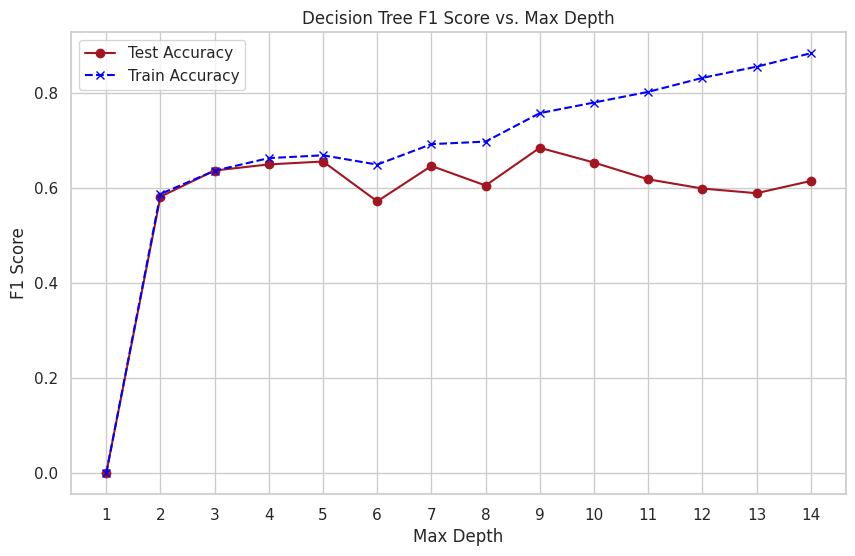

In [ ]:
max_depth_values = range(1, 15)
accuracies_dt_test = []
accuracies_dt_train = []

for depth in max_depth_values:
    model = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))])
    model.fit(X_train_encoded, y_train)
    accuracies_dt_test.append(f1_score(model.predict(X_test_encoded), y_test))
    accuracies_dt_train.append(f1_score(model.predict(X_train_encoded), y_train))

plt.figure(figsize=(10, 6))
plt.plot(max_depth_values, accuracies_dt_test, marker='o', color='#A31621', label='Test Accuracy')
plt.plot(max_depth_values, accuracies_dt_train, marker='x', color='blue', linestyle='--', label='Train Accuracy')
plt.title('Decision Tree F1 Score vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.xticks(np.arange(min(max_depth_values), max(max_depth_values)+1, 1))
plt.grid(True)
plt.legend()
plt.show()

### 3. Final Optimization: Grid Search and Cross-Validation
We will use `GridSearchCV` to find the optimal combination of hyperparameters for the Decision Tree.

In [ ]:
param_grid_dt = {
    "model__max_depth": [3, 5, 7, 9],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["gini", "entropy"]
}

grid_search_dt = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))]), param_grid_dt, cv=5, scoring="f1", n_jobs=-1)
grid_search_dt.fit(X_train_encoded, y_train)

print(f"Best Decision Tree parameters: {grid_search_dt.best_params_}")
print(f"Best Decision Tree f1 score (CV): {grid_search_dt.best_score_:.4f}")

best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test_encoded)
print(f"Final Decision Tree F1 Score on Test Set: {f1_score(y_test, y_pred_dt):.4f}")

Best Decision Tree parameters: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 4}
Best Decision Tree f1 score (CV): 0.6489
Final Decision Tree F1 Score on Test Set: 0.6590


### Decision Tree Visualization of the Best Model

Let's visualize the structure of the optimized Decision Tree to understand its decision-making process. We will limit the depth for better readability.

In [ ]:
best_dt_model['model']

DecisionTreeClassifier(max_depth=5, min_samples_leaf=4, random_state=42)

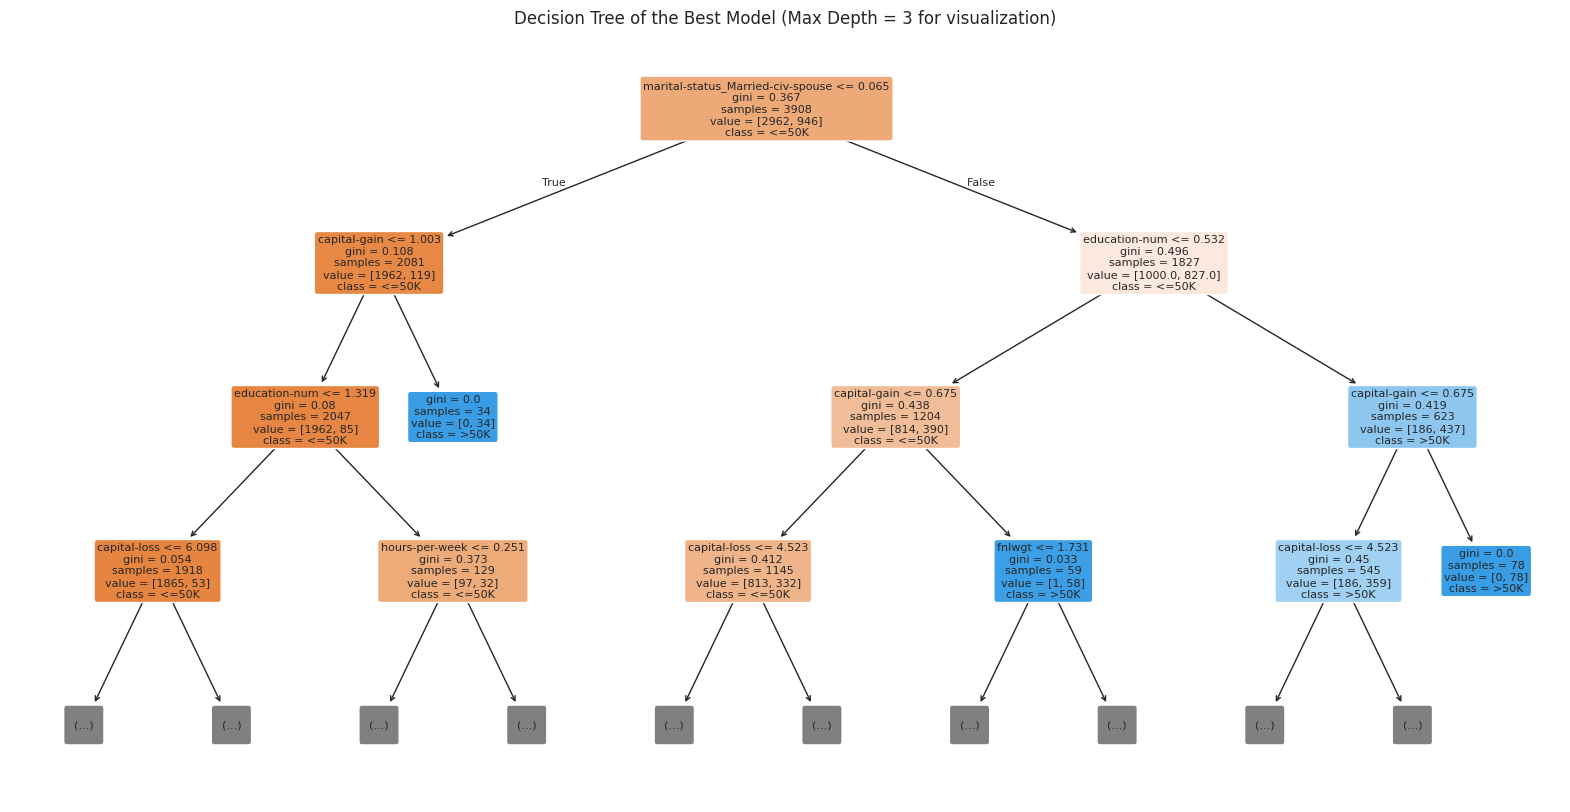

In [ ]:
plt.figure(figsize=(20, 10))

# Map the 0/1 target back to original labels for plotting clarity
class_names = ['<=50K', '>50K']

plot_tree(best_dt_model['model'],
          feature_names=train_cols,
          class_names=class_names,
          filled=True,
          rounded=True,
          max_depth=3, # Limit depth for better visualization
          fontsize=8)
plt.title('Decision Tree of the Best Model (Max Depth = 3 for visualization)')
plt.show()

### Feature Importance from the Best Decision Tree Model

Decision Trees provide a way to understand which features were most influential in making decisions. Let's extract and visualize these importances from our optimized model.

Top 10 Feature Importances:


,Feature,Importance
29,marital-status_Married-civ-spouse,0.465725
2,education-num,0.226577
3,capital-gain,0.200872
4,capital-loss,0.069522
5,hours-per-week,0.025511
1,fnlwgt,0.008614
8,workclass_Private,0.003179
0,age,0.000000
6,workclass_Local-gov,0.000000
9,workclass_Self-emp-inc,0.000000


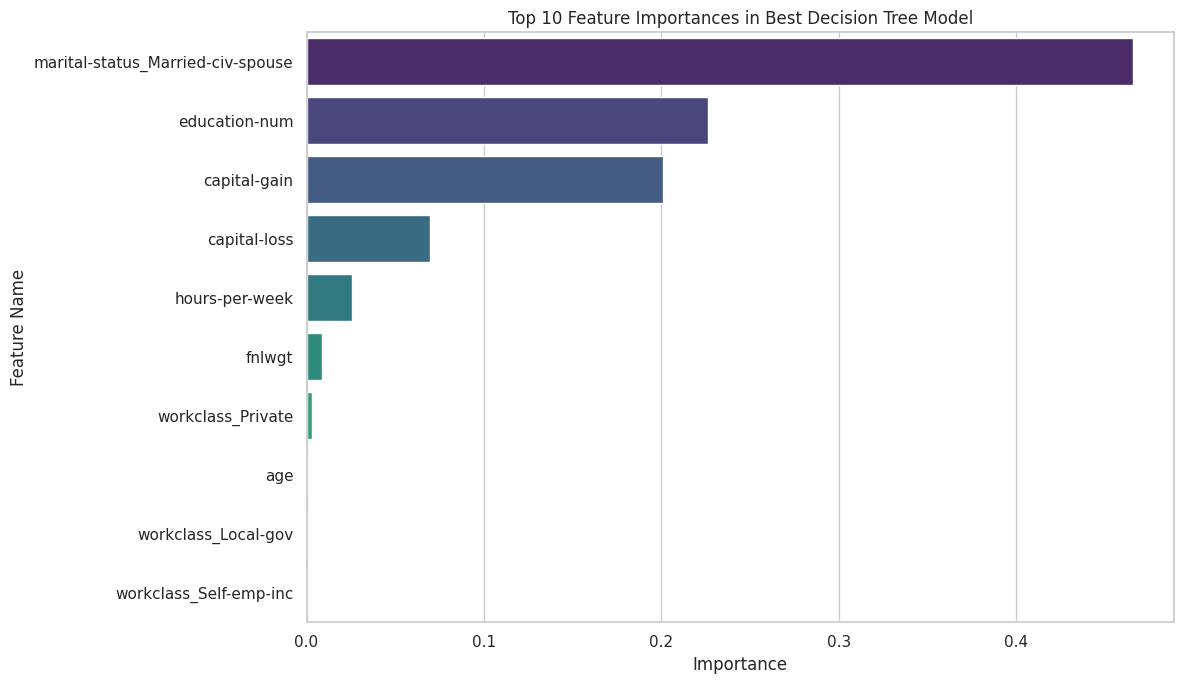

In [ ]:
# Get feature importances
importances = best_dt_model['model'].feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': train_cols,
    'Importance': importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(feature_importance_df.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances in Best Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 3. Ensemble Methods

Ensemble methods combine the predictions of multiple models to achieve better and more robust performance than a single model. This is based on the principle of the "wisdom of the crowd".

### Random Forests (Bagging)
Random Forests build a large number of independent decision trees. Each tree is trained on a random subset of the training data (bootstrapping) and considers only a random subset of features for splitting at each node. The final prediction is made by aggregating the predictions of individual trees (e.g., majority vote for classification). This process reduces variance and prevents overfitting.

### 1. Baseline Performance (Default Parameters)
Let's train a Random Forest model with default parameters and evaluate its performance.

In [ ]:
# Train Random Forest with default parameters
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train_encoded, y_train)
y_pred_rf_default = rf_default.predict(X_test_encoded)
print(f"Random Forest (default) Accuracy: {f1_score(y_test, y_pred_rf_default):.4f}")

Random Forest (default) Accuracy: 0.6801


### 2. Hyperparameter Impact Analysis
Key hyperparameters for Random Forests include:
*   `n_estimators`: The number of trees in the forest. More trees generally lead to better performance but increase computation time.
*   `max_features`: The number of features to consider when looking for the best split. A smaller value introduces more randomness and reduces correlation between trees.
*   `max_depth`: Controls the complexity of individual trees within the forest.

Let's see the impact of `n_estimators`.

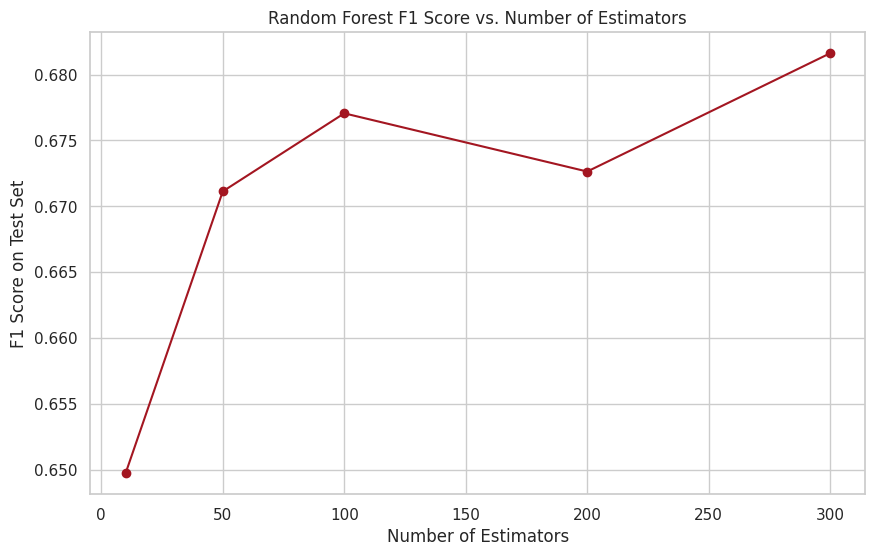

In [ ]:
n_estimators_values = [10, 50, 100, 200, 300]
accuracies_rf = []

for n in n_estimators_values:
    model = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=n, random_state=42))])
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    accuracies_rf.append(f1_score(y_pred, y_test))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, accuracies_rf, marker='o', color='#A31621')
plt.title('Random Forest F1 Score vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('F1 Score on Test Set')
plt.grid(True)
plt.show()

### 3. Final Optimization: Grid Search and Cross-Validation
We will use `GridSearchCV` to find the optimal combination of hyperparameters for the Random Forest.

In [ ]:
param_grid_rf = {
    "model__n_estimators": [100],
    "model__max_features": ["sqrt", "log2"],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 2, 4],
}

grid_search_rf = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(random_state=42))]), param_grid_rf, cv=5, scoring="f1", n_jobs=-1)
grid_search_rf.fit(X_train_encoded, y_train)

print(f"Best Random Forest parameters: {grid_search_rf.best_params_}")
print(f"Best Random Forest accuracy (CV): {grid_search_rf.best_score_:.4f}")

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_encoded)
print(f"Final Random Forest F1 score on Test Set: {f1_score(y_test, y_pred_rf):.4f}")

Best Random Forest parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best Random Forest accuracy (CV): 0.6760
Final Random Forest F1 score on Test Set: 0.6771


### Feature Importance from the Best Random Forest Model

Let's examine which features were most influential in the optimized Random Forest model.

Top 10 Feature Importances for Random Forest:


,Feature,Importance
1,fnlwgt,0.132210
0,age,0.130605
29,marital-status_Married-civ-spouse,0.091276
3,capital-gain,0.088335
5,hours-per-week,0.082893
2,education-num,0.074362
31,marital-status_Never-married,0.036151
4,capital-loss,0.030014
47,relationship_Not-in-family,0.019933
56,sex_Male,0.018944


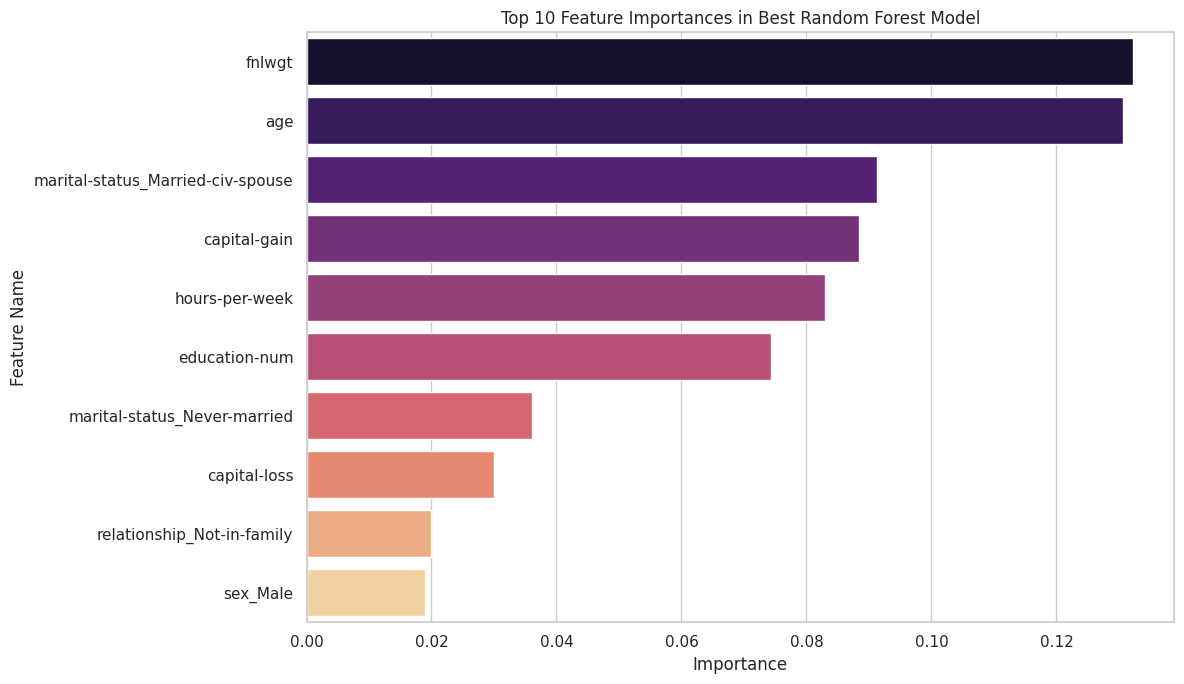

In [ ]:
# Get feature importances from the best Random Forest model
importances_rf = best_rf_model['model'].feature_importances_

# Create a DataFrame for better visualization
feature_importance_df_rf = pd.DataFrame({
    'Feature': train_cols,
    'Importance': importances_rf
})

# Sort by importance in descending order
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances for Random Forest:")
display(feature_importance_df_rf.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf.head(10), palette='magma')
plt.title('Top 10 Feature Importances in Best Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Gradient Boosting
Gradient Boosting builds trees sequentially, where each new tree attempts to correct the errors made by previous trees. It focuses on improving the predictions of the ensemble by iteratively adding weak learners (typically shallow decision trees). It is a very powerful method but more susceptible to overfitting if not well-calibrated.

### 1. Baseline Performance (Default Parameters)
Let's train a Gradient Boosting model with default parameters and evaluate its performance.

In [ ]:
# Train Gradient Boosting with default parameters
gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_train_encoded, y_train)
y_pred_gb_default = gb_default.predict(X_test_encoded)
print(f"Gradient Boosting (default) F1 Score: {f1_score(y_test, y_pred_gb_default):.4f}")

Gradient Boosting (default) F1 Score: 0.6807


### 2. Hyperparameter Impact Analysis
Key hyperparameters for Gradient Boosting include:
*   `n_estimators`: The number of boosting stages (i.e., the number of weak learners). More estimators can lead to better performance but also to overfitting.
*   `learning_rate`: Shrinks the contribution of each tree. A smaller learning rate requires more estimators but makes the model more robust.
*   `max_depth`: Controls the complexity of individual weak learners (trees).

Let's see the impact of `learning_rate`.

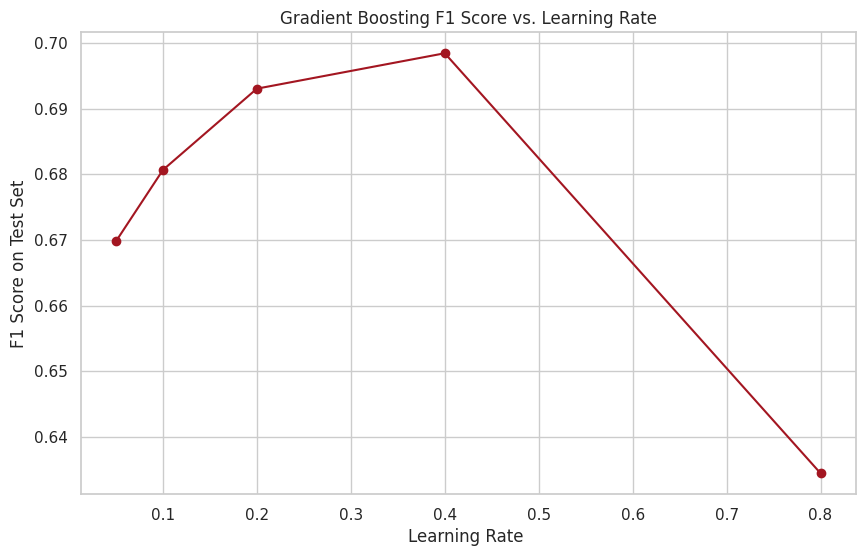

In [ ]:
learning_rate_values = [0.05, 0.1, 0.2, 0.4, 0.8]
accuracies_gb = []

for lr in learning_rate_values:
    model = Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingClassifier(learning_rate=lr, n_estimators=100, random_state=42))])
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    accuracies_gb.append(f1_score(y_pred, y_test))

plt.figure(figsize=(10, 6))
plt.plot(learning_rate_values, accuracies_gb, marker='o', color='#A31621')
plt.title('Gradient Boosting F1 Score vs. Learning Rate')
plt.xlabel('Learning Rate ')
plt.ylabel('F1 Score on Test Set')
plt.grid(True)
plt.show()

### 3. Final Optimization: Grid Search and Cross-Validation
We will use `GridSearchCV` to find the optimal combination of hyperparameters for Gradient Boosting.

In [ ]:
param_grid_gb = {
    "model__learning_rate": [0.3, 0.4, 0.5],
    "model__max_depth": [2, 3, 5]
}

grid_search_gb = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingClassifier(random_state=42))]), param_grid_gb, cv=3, scoring="f1")
grid_search_gb.fit(X_train_encoded, y_train)

print(f"Best Gradient Boosting parameters: {grid_search_gb.best_params_}")
print(f"Best Gradient Boosting accuracy (CV): {grid_search_gb.best_score_:.4f}")

best_gb_model = grid_search_gb.best_estimator_
y_pred_gb = best_gb_model.predict(X_test_encoded)
print(f"Final Gradient Boosting F1 score on Test Set: {f1_score(y_test, y_pred_gb):.4f}")

Best Gradient Boosting parameters: {'model__learning_rate': 0.5, 'model__max_depth': 3}
Best Gradient Boosting accuracy (CV): 0.6874
Final Gradient Boosting F1 score on Test Set: 0.6966


## 4. Support Vector Machines (SVM)

Support Vector Machines (SVMs) are powerful and versatile machine learning models capable of performing linear or non-linear classification, regression, and even outlier detection. They work by finding the hyperplane that best separates the classes in the feature space, maximizing the margin between the closest data points of each class (support vectors).

### The Kernel Trick
The Kernel Trick allows SVMs to find non-linear decision boundaries by implicitly mapping the data into a higher-dimensional space where it becomes linearly separable. Common kernels include `linear`, `poly` (polynomial), and `rbf` (Radial Basis Function).

### 1. Baseline Performance (Default Parameters)
Let's train an SVM model with default parameters (RBF kernel, C=1.0) and evaluate its performance.

In [ ]:
# Train SVM with default parameters
# svm_default = SVC(random_state=42, probability=True)
svm_default = Pipeline([('scaler', StandardScaler()), ('model',SVC(random_state=42, probability=True))])
svm_default.fit(X_train_encoded, y_train)
y_pred_svm_default = svm_default.predict(X_test_encoded)
print(f"SVM (default) F1 Score: {f1_score(y_test, y_pred_svm_default):.4f}")

SVM (default) F1 Score: 0.6066


### 2. Hyperparameter Impact Analysis
Key hyperparameters for SVMs include:
*   `C`: The regularization parameter. A smaller `C` leads to a wider margin but more misclassifications (stronger regularization), while a larger `C` aims for fewer misclassifications but a narrower margin (weaker regularization).
*   `kernel`: Specifies the kernel type to be used in the algorithm (e.g., "linear", "poly", "rbf").

Let's evaluate the performance of SVM with different kernel types: 'linear', 'poly' (polynomial with various degrees), and 'rbf' (Radial Basis Function), comparing both training and testing accuracies.

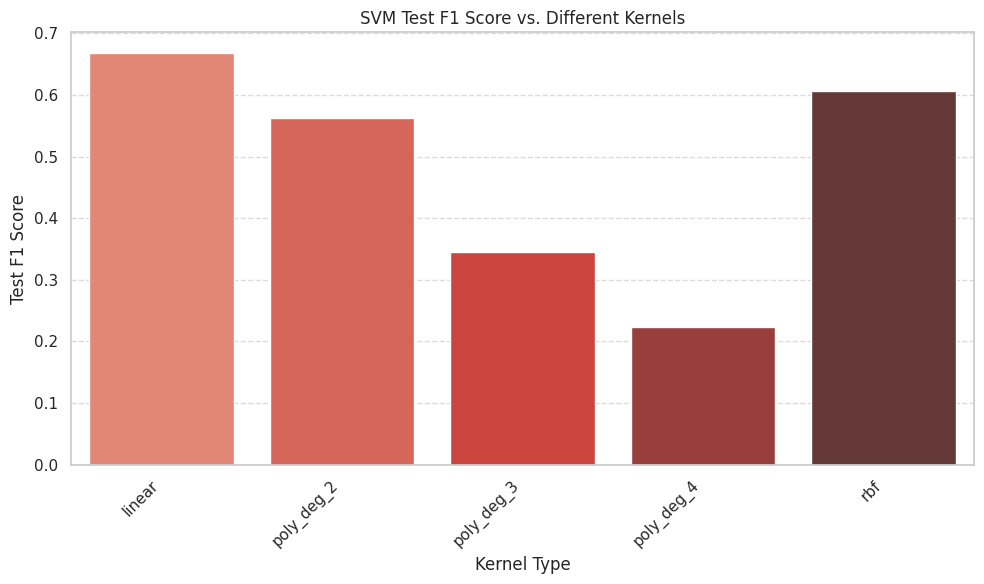

In [ ]:
kernels_to_test = {
    'linear': 'linear',
    'poly_deg_2': ('poly', 2),
    'poly_deg_3': ('poly', 3),
    'poly_deg_4': ('poly', 4),
    'rbf': 'rbf'
}

accuracies_test_kernels = {}

for kernel_name, kernel_params in kernels_to_test.items():
    if isinstance(kernel_params, tuple):
        kernel_type, degree = kernel_params
        model = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel=kernel_type, degree=degree, random_state=42))])
    else:
        model = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel=kernel_params, random_state=42))])

    model.fit(X_train_encoded, y_train)
    y_pred_test = model.predict(X_test_encoded)
    accuracies_test_kernels[kernel_name] = f1_score(y_test, y_pred_test)

# Create DataFrame for plotting test accuracy only
kernel_performance_test_df = pd.DataFrame(accuracies_test_kernels.items(), columns=['Kernel', 'Test F1 Score'])

# Plotting kernel performance
plt.figure(figsize=(10, 6))
sns.barplot(x='Kernel', y='Test F1 Score', data=kernel_performance_test_df, palette='Reds_d')

plt.title('SVM Test F1 Score vs. Different Kernels')
plt.xlabel('Kernel Type')
plt.ylabel('Test F1 Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's explore the impact of the `C` parameter.

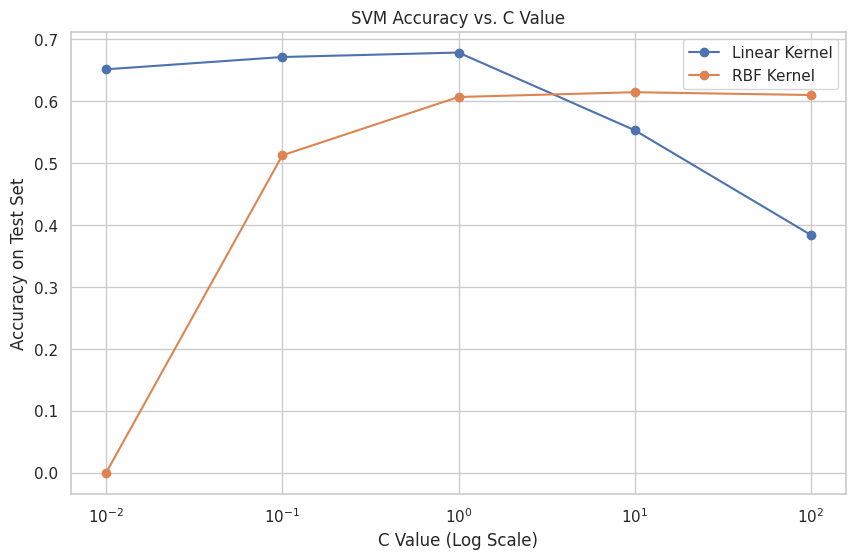

In [ ]:
c_values_svm = [0.01, 0.1, 1, 10, 100]

accuracies_rbf_svm = []
accuracies_linear_svm = []
for c in c_values_svm:
    model = Pipeline([('scaler', StandardScaler()), ('model',SVC(C=c, kernel='linear', random_state=42, max_iter=10000))])
    model.fit(X_train_encoded, y_train)
    accuracies_linear_svm.append(f1_score(model.predict(X_test_encoded), y_test))

accuracies_rbf_svm = []
for c in c_values_svm:
    model = Pipeline([('scaler', StandardScaler()), ('model',SVC(C=c, kernel='rbf',random_state=42, max_iter=10000))])
    model.fit(X_train_encoded, y_train)
    accuracies_rbf_svm.append(f1_score(model.predict(X_test_encoded), y_test))

plt.figure(figsize=(10, 6))
plt.plot(c_values_svm, accuracies_linear_svm, marker='o')
plt.plot(c_values_svm, accuracies_rbf_svm, marker='o')
plt.xscale('log')
plt.title('SVM Accuracy vs. C Value')
plt.xlabel('C Value (Log Scale)')
plt.ylabel('Accuracy on Test Set')
plt.legend(['Linear Kernel', 'RBF Kernel'])
plt.grid(True)
plt.show()

### 3. Final Optimization: Grid Search and Cross-Validation
We will use `GridSearchCV` to find the optimal combination of hyperparameters for the SVM.

In [ ]:
param_grid_svm = {
    "model__C": [ 0.1, 1, 100],
    "model__kernel": ["linear", "rbf"]
}

grid_search_svm = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('model',SVC(random_state=42, max_iter=10000))]), param_grid_svm, cv=5, scoring="f1")
grid_search_svm.fit(X_train_encoded, y_train)

print(f"Best SVM parameters: {grid_search_svm.best_params_}")
print(f"Best SVM accuracy (CV): {grid_search_svm.best_score_:.4f}")

best_svm_model = grid_search_svm.best_estimator_
y_pred_svm = best_svm_model.predict(X_test_encoded)
print(f"Final SVM F1 Score on Test Set: {f1_score(y_test, y_pred_svm):.4f}")

Best SVM parameters: {'model__C': 0.1, 'model__kernel': 'linear'}
Best SVM accuracy (CV): 0.6593
Final SVM F1 Score on Test Set: 0.6712


## 5. Naïve Bayes

### Theoretical Description
Naïve Bayes is a family of classification algorithms based on **Bayes' Theorem** with a "naïve" assumption of **independence between features**. Despite this strong (and often unrealistic) assumption, Naïve Bayes classifiers are simple, fast, and often perform surprisingly well, especially for text classification (e.g., spam detection).

### 1. Baseline Performance (Default Parameters)
Let's train a Naïve Bayes model with default parameters and evaluate its performance.

In [ ]:
# Train Naïve Bayes with default parameters
nb_default = GaussianNB()
# nb_default = Pipeline([('scaler', StandardScaler()), ('model',GaussianNB())])

nb_default.fit(X_train_encoded, y_train)
y_pred_nb_default = nb_default.predict(X_test_encoded)
print(f"Naïve Bayes (default) F1 Score: {f1_score(y_test, y_pred_nb_default):.4f}")

Naïve Bayes (default) F1 Score: 0.4124


## 6. Model Selection and Final Considerations

We have explored various classification algorithms. The choice of the best model depends on many factors, including the nature of the data, performance requirements, interpretability, and computational resources.

### Performance Summary (on Test Set)
Let's compare the final accuracy of all optimized models on the test set.

In [ ]:
# Collect accuracies of all best models
accuracies = {
    "Decision Tree": f1_score(y_test, y_pred_dt),
    "Random Forest": f1_score(y_test, y_pred_rf),
    "Gradient Boosting": f1_score(y_test, y_pred_gb),
    "SVM (Linear)": f1_score(y_test, y_pred_svm)
}

performance_df = pd.DataFrame(accuracies.items(), columns=["Model", "Accuracy"])
performance_df = performance_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print(performance_df)

               Model  Accuracy
0  Gradient Boosting  0.696629
1      Random Forest  0.677060
2       SVM (Linear)  0.671202
3      Decision Tree  0.659039


## 8. Naïve Bayes on Document Classification

Given that Naïve Bayes performed relatively poorly on the Adult Income dataset (due to its strong independence assumption not holding well for tabular data), let's see how it performs on a task where it is well-suited: **document classification**. We will use the 20 Newsgroups dataset.

In [ ]:
# Import necessary libraries for text processing
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Load the 20 Newsgroups dataset
# We'll load a subset to keep the example concise
print("Loading 20 Newsgroups dataset...")
newsgroups_train = fetch_20newsgroups(subset='train', categories=['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian'], shuffle=True, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', categories=['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian'], shuffle=True, random_state=42)

X_train_docs, y_train_docs = newsgroups_train.data, newsgroups_train.target
X_test_docs, y_test_docs = newsgroups_test.data, newsgroups_test.target

print(f"Number of training documents: {len(X_train_docs)}")
print(f"Number of testing documents: {len(X_test_docs)}")
print(f"Categories: {newsgroups_train.target_names}")

Loading 20 Newsgroups dataset...
Number of training documents: 2257
Number of testing documents: 1502
Categories: ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']


### TF-IDF Vectorization

Text data needs to be converted into numerical features that machine learning algorithms can understand. TF-IDF (Term Frequency-Inverse Document Frequency) is a common technique for this, reflecting the importance of a word in a document relative to a collection of documents.

In [ ]:
# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, norm=None) # Limit features for speed

# Fit the vectorizer on the training data and transform both train and test data
X_train_tfidf = vectorizer.fit_transform(X_train_docs)
X_test_tfidf = vectorizer.transform(X_test_docs)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (2257, 5000)
Shape of X_test_tfidf: (1502, 5000)


In [ ]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 192293 stored elements and shape (2257, 5000)>
  Coords	Values
  (0, 920)	18.716733907500227
  (0, 205)	7.436576877528297
  (0, 4665)	7.036456115265624
  (0, 2867)	11.681763022221919
  (0, 4345)	1.0
  (0, 1116)	12.839299303431124
  (0, 2236)	4.431775303561216
  (0, 2182)	10.333773366440388
  (0, 2223)	11.088361828723324
  (0, 3069)	2.165456388551565
  (0, 3452)	2.0413800659193924
  (0, 2175)	2.145765175661383
  (0, 3198)	1.057418959423872
  (0, 4698)	3.909783238888431
  (0, 2619)	1.0039937927502915
  (0, 26)	3.5517507496714558
  (0, 1430)	2.2498884502087066
  (0, 2515)	2.0706628711198802
  (0, 1988)	2.5422180910570344
  (0, 4871)	2.5801973391222512
  (0, 4274)	4.087505756479972
  (0, 3308)	4.644697300803887
  (0, 398)	5.008662678005299
  (0, 3312)	5.831862986813443
  (0, 4742)	5.949646022469826
  :	:
  (2256, 763)	4.984565126426239
  (2256, 2080)	4.830414446598981
  (2256, 2770)	4.830414446598981
  (2256, 3431)	5.08464858498

### Training and Evaluation of Multinomial Naïve Bayes

Multinomial Naïve Bayes is particularly suitable for classification with discrete features (like word counts or TF-IDF values), as it models the probability of observing features for a given class. Let's train and evaluate it on our vectorized text data.

In [ ]:
# Train a Multinomial Naïve Bayes classifier
mnb_classifier = MultinomialNB()
mnb_classifier.fit(X_train_tfidf, y_train_docs)

# Make predictions on the test set
y_pred_mnb = mnb_classifier.predict(X_test_tfidf)

# Evaluate the classifier
print(f"Multinomial Naïve Bayes Accuracy on Document Classification: {accuracy_score(y_test_docs, y_pred_mnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_docs, y_pred_mnb, target_names=newsgroups_test.target_names))

Multinomial Naïve Bayes Accuracy on Document Classification: 0.9308

Classification Report:
                        precision    recall  f1-score   support

           alt.atheism       0.91      0.90      0.91       319
         comp.graphics       0.96      0.95      0.95       389
               sci.med       0.93      0.93      0.93       396
soc.religion.christian       0.92      0.94      0.93       398

              accuracy                           0.93      1502
             macro avg       0.93      0.93      0.93      1502
          weighted avg       0.93      0.93      0.93      1502



### Training and Evaluation of Random Forest Classifier on Document Classification

Let's train a Random Forest classifier on the TF-IDF vectorized text data and compare its performance to Naïve Bayes.

In [ ]:
# Train a Random Forest classifier
rf_text_classifier = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1) # Use n_jobs=-1 for parallel processing
rf_text_classifier.fit(X_train_tfidf, y_train_docs)

# Make predictions on the test set
y_pred_rf_text = rf_text_classifier.predict(X_test_tfidf)

# Evaluate the classifier
print(f"Random Forest Accuracy on Document Classification: {accuracy_score(y_test_docs, y_pred_rf_text):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_docs, y_pred_rf_text, target_names=newsgroups_test.target_names))

Random Forest Accuracy on Document Classification: 0.8609

Classification Report:
                        precision    recall  f1-score   support

           alt.atheism       0.95      0.72      0.82       319
         comp.graphics       0.78      0.96      0.86       389
               sci.med       0.91      0.78      0.84       396
soc.religion.christian       0.87      0.96      0.91       398

              accuracy                           0.86      1502
             macro avg       0.88      0.85      0.86      1502
          weighted avg       0.87      0.86      0.86      1502



As you can see, Naïve Bayes achieves a much higher accuracy and F1-score on the document classification task, demonstrating its suitability for certain types of data and problems.

### Exercise: Optimize Text Classifiers with Grid Search

Perform a grid search with cross-validation to find the optimal hyperparameters for `MultinomialNB` and `RandomForestClassifier` on the 20 Newsgroups dataset. Consider tuning parameters like `alpha` for `MultinomialNB` and `n_estimators`, `max_depth`, and `min_samples_leaf` for `RandomForestClassifier`.

Compare the performance of the optimized models with their baseline performances and the optimized models from the Adult Income dataset.